# Prueba del método SSGrad-CAM++

Cargamos las librerías necesarias, fijamos las rutas al modelo entrenado y a las imágenes
de validación, y fijamos una semilla aleatoria para que los resultados sean siempre
reproducibles.

In [1]:
import random
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from ultralytics import YOLO
from ultralytics.utils.ops import scale_boxes, xywh2xyxy
from ultralytics.utils.tal import make_anchors

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

sys.path.insert(0, str(REPO_ROOT / "src"))
from xai_benchmark.data.kitti_dataset import KITTI_CLASSES, load_kitti_yolo_bboxes
from xai_benchmark.detection.yolo_head import get_one2many_predictions
from xai_benchmark.uncertainty.tta import box_iou

CHECKPOINT = REPO_ROOT / "results/runs/detect/finetune_stage2_unfrozen/weights/best.pt"
VAL_IMAGES_DIR = REPO_ROOT / "data/kitti/images/val"
VAL_LABELS_DIR = REPO_ROOT / "data/kitti/labels/val"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONF_THRES = 0.25      
IOU_THRES_NMS = 0.5
EPS = 1e-8

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

Cargamos el modelo entrenado dos veces: una copia (`model_dense`) que usaremos para
calcular gradientes internos (necesario para el método), y otra (`model_prep`) que solo
usamos por su utilidad de preprocesado de imágenes. Confirmamos que la cabeza de detección
tiene 3 escalas y 8 clases, como corresponde a YOLO26 entrenado sobre KITTI.

In [2]:
model_dense = YOLO(str(CHECKPOINT))
model_dense.model.to(DEVICE)
model_dense.model.eval()
model_dense.model.requires_grad_(True)

model_prep = YOLO(str(CHECKPOINT))
_dummy = np.zeros((640, 640, 3), dtype=np.uint8)
model_prep.predict([_dummy], verbose=False, device=0 if DEVICE == "cuda" else "cpu")

detect_head = model_dense.model.model[-1]
assert detect_head.__class__.__name__ == "Detect", f"Se esperaba Detect, se obtuvo {detect_head.__class__.__name__}"
NUM_SCALES = detect_head.nl     
NUM_CLASSES = detect_head.nc
print(f"Cabeza Detect: {NUM_SCALES} escalas, {NUM_CLASSES} clases, stride={detect_head.stride.tolist()}")

Cabeza Detect: 3 escalas, 8 clases, stride=[8.0, 16.0, 32.0]



SSGrad-CAM++ necesita observar qué pasa *dentro* del modelo mientras predice, no solo el
resultado final. Usamos 6 puntos de escucha (2 por cada una de las 3 escalas)
que capturan, en cada predicción, la activación interna de la red y la puntuación de cada
clase justo antes de convertirla en probabilidad.

In [3]:
activations = [None] * NUM_SCALES   
logits = [None] * NUM_SCALES        

def _activation_hook(scale_idx):
    def _hook(module, inp, out):
        if out.requires_grad:      
            out.retain_grad()      
        activations[scale_idx] = out
    return _hook

def _logit_hook(scale_idx):
    def _hook(module, inp, out):
        logits[scale_idx] = out
    return _hook

_hook_handles = []
for s in range(NUM_SCALES):
    branch = detect_head.cv3[s]
    _hook_handles.append(branch[1].register_forward_hook(_activation_hook(s)))
    _hook_handles.append(branch[2].register_forward_hook(_logit_hook(s)))

print(f"{len(_hook_handles)} hooks registrados ({NUM_SCALES} escalas x 2)")

6 hooks registrados (3 escalas x 2)


Cuando el modelo detecta un objeto, esa detección nace en realidad de una celda muy concreta
de una rejilla interna — pero esa información no aparece en el resultado final, solo la caja
y la clase. Estas funciones auxiliares recuperan esa celda: vuelven a ejecutar el modelo
permitiendo el cálculo de gradientes, identifican qué celda generó la detección que queremos
explicar, y comprueban (con una utilidad propia de Ultralytics) que esa celda está bien
localizada.

In [4]:
def dense_forward_with_grad(model_dense, imgs_tensor):
    """Replica la parte relevante de get_one2many_predictions sin @torch.no_grad(). 
    Devuelve (1, anclas, 4+nc) en formato xywh + sigmoide, igual que en yolo_head.py, y repuebla
    `activations`/`logits` via los hooks de la Celda 3."""
    detection_model = model_dense.model
    prev_end2end = detection_model.end2end
    detection_model.end2end = False
    try:
        raw, _ = detection_model(imgs_tensor)
    finally:
        detection_model.end2end = prev_end2end
    return raw.permute(0, 2, 1)  # (1, anclas, 4+nc)

In [5]:
def locate_anchor(model_dense, imgs_tensor, orig_shape, target_box_xyxy, target_class_idx, iou_match_thres=0.999):
    raw = dense_forward_with_grad(model_dense, imgs_tensor)[0]  # (anclas, 4+nc)
    boxes_xywh, class_probs = raw.split([4, NUM_CLASSES], dim=-1)
    boxes_xyxy_letterboxed = xywh2xyxy(boxes_xywh)
    img1_shape = imgs_tensor.shape[2:]
    boxes_xyxy_orig = scale_boxes(img1_shape, boxes_xyxy_letterboxed.clone().detach(), orig_shape)

    target = torch.as_tensor(target_box_xyxy, dtype=boxes_xyxy_orig.dtype, device=boxes_xyxy_orig.device).unsqueeze(0)
    ious = box_iou(boxes_xyxy_orig, target).squeeze(-1)
    pred_class = class_probs.detach().argmax(dim=-1)
    candidates = ((ious >= iou_match_thres) & (pred_class == target_class_idx)).nonzero(as_tuple=True)[0]

    if len(candidates) == 0:
        raise RuntimeError("Ninguna ancla reproduce esta deteccion -- revisar conf_thres/iou_match_thres.")
    if len(candidates) > 1:
        print(f"Aviso: {len(candidates)} anclas coinciden; se usa la de mayor confianza.")
        candidates = candidates[[class_probs[candidates, target_class_idx].argmax()]]
    return int(candidates[0])

In [ ]:
def anchor_index_to_cell(anchor_idx, activations):
    offset = 0
    for s in range(NUM_SCALES):
        _, _, H_s, W_s = activations[s].shape
        n_s = H_s * W_s
        if anchor_idx < offset + n_s:
            local_idx = anchor_idx - offset
            row, col = divmod(local_idx, W_s)  
            return s, row, col, H_s, W_s
        offset += n_s
    raise ValueError(f"anchor_idx {anchor_idx} fuera de rango (total anclas: {offset})")

In [7]:
def verify_cell_ordering(anchor_idx, boxes_xyxy_letterboxed):
    feats = [activations[s] for s in range(NUM_SCALES)]
    anchor_points, stride_tensor = make_anchors(feats, detect_head.stride, 0.5)
    point_xy = (anchor_points[anchor_idx] * stride_tensor[anchor_idx]).detach()
    box = boxes_xyxy_letterboxed[anchor_idx].detach()
    center = torch.tensor([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2], device=box.device)
    print(f"Punto de ancla (make_anchors): {point_xy.tolist()}")
    print(f"Centro de la caja decodificada: {center.tolist()}")
    print(f"Diferencia: {(point_xy - center).abs().tolist()} px (debe ser pequena, del orden del stride de esa escala)")

Probamos todo lo anterior sobre una imagen real del conjunto de validación (`004018`).
El modelo detecta un coche, una furgoneta y un tranvía.

In [ ]:
image_id = "004018"  # imagen real del val set (mayor incertidumbre agregada, tta_uq_analysis.ipynb Celda 7)
img_path = VAL_IMAGES_DIR / f"{image_id}.png"
label_path = VAL_LABELS_DIR / f"{image_id}.txt"

assert img_path.exists(), f"No existe {img_path}"
img_bgr = cv2.imread(str(img_path))
assert img_bgr is not None, f"cv2.imread devolvio None para {img_path}"

orig_shape = img_bgr.shape[:2]
gt_labels = load_kitti_yolo_bboxes(str(label_path), orig_shape[0], orig_shape[1], return_class=True, box_format="xyxy")

imgs_tensor = model_prep.predictor.preprocess([img_bgr])
dets = get_one2many_predictions(model_dense, imgs_tensor, [orig_shape], conf_thres=CONF_THRES, iou_thres=IOU_THRES_NMS)
det = dets[0]

for i in range(len(det.boxes)):
    cls_idx = int(det.class_probs[i].argmax())
    print(f"[{i}] clase={KITTI_CLASSES.get(cls_idx, '?')} conf={det.max_conf[i]:.3f} caja={det.boxes[i].tolist()}")

[0] clase=car conf=0.888 caja=[597.9949340820312, 187.30177307128906, 638.56494140625, 217.0601043701172]
[1] clase=van conf=0.751 caja=[656.4490356445312, 178.19863891601562, 698.5503540039062, 217.90972900390625]
[2] clase=tram conf=0.659 caja=[504.3553466796875, 167.7240447998047, 583.6945190429688, 206.99375915527344]


Para comprobar que funciona la recuperación de celda, elegimos el coche detectado y recuperamos la celda de la que nace esa detección: celda
(15, 40) de la escala más fina (stride 8). La diferencia entre la posición teórica de esa
celda y el centro de la caja detectada es de apenas ~5 píxeles — pequeña, como se espera.
También comprobamos que la puntuación interna del modelo para esa celda, al convertirla en
probabilidad, coincide con la confianza que el modelo reportó (0.8876 ≈ 0.888): buena señal
de que hemos encontrado la celda correcta.

In [ ]:
OBJ_IDX = 0  

target_box = det.boxes[OBJ_IDX]
target_class = int(det.class_probs[OBJ_IDX].argmax())
print(f"Explicando objeto {OBJ_IDX}: clase={KITTI_CLASSES.get(target_class, '?')} caja={target_box.tolist()}")

model_dense.model.zero_grad(set_to_none=True)
anchor_idx = locate_anchor(model_dense, imgs_tensor, orig_shape, target_box.tolist(), target_class)
scale_idx, row, col, H_s, W_s = anchor_index_to_cell(anchor_idx, activations)
print(f"Ancla: indice={anchor_idx} -> escala={scale_idx} (stride {int(detect_head.stride[scale_idx])}), celda=({row},{col}) de {H_s}x{W_s}")

raw_check = dense_forward_with_grad(model_dense, imgs_tensor)[0]
boxes_xywh_check, _ = raw_check.split([4, NUM_CLASSES], dim=-1)
boxes_xyxy_letterboxed_check = xywh2xyxy(boxes_xywh_check)
verify_cell_ordering(anchor_idx, boxes_xyxy_letterboxed_check)

Explicando objeto 0: clase=car caja=[597.9949340820312, 187.30177307128906, 638.56494140625, 217.0601043701172]
Ancla: indice=1240 -> escala=0 (stride 8), celda=(15,40) de 28x80
Punto de ancla (make_anchors): [324.0, 124.0]
Centro de la caja decodificada: [318.5983581542969, 119.18341064453125]
Diferencia: [5.401641845703125, 4.81658935546875] px (debe ser pequena, del orden del stride de esa escala)


Para estar aun más seguros, realizamos lo mismo para un conjunto aleatorio de imágenes

In [ ]:
import random
random.seed(SEED)

N_SAMPLES = 15
pool = pd.read_csv(REPO_ROOT / "results/tta_uq/object_level.csv", dtype={"image_id": str})
sample_rows = pool.sample(n=N_SAMPLES, random_state=SEED)

for _, r in sample_rows.iterrows():
    image_id = r["image_id"]
    img_bgr = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    if img_bgr is None:
        continue
    orig_shape = img_bgr.shape[:2]
    imgs_tensor = model_prep.predictor.preprocess([img_bgr])
    dets = get_one2many_predictions(model_dense, imgs_tensor, [orig_shape], conf_thres=CONF_THRES, iou_thres=IOU_THRES_NMS)[0]
    if len(dets.boxes) == 0:
        continue
    obj_idx = random.randrange(len(dets.boxes))
    target_box = dets.boxes[obj_idx].tolist()
    target_class = int(dets.class_probs[obj_idx].argmax())
    conf_original = float(dets.max_conf[obj_idx])

    model_dense.model.zero_grad(set_to_none=True)
    anchor_idx = locate_anchor(model_dense, imgs_tensor, orig_shape, target_box, target_class)
    scale_idx, cell_row, cell_col, H_s, W_s = anchor_index_to_cell(anchor_idx, activations)
    conf_recovered = torch.sigmoid(logits[scale_idx][0, target_class, cell_row, cell_col]).item()

    anchor_points, _ = make_anchors([activations[s] for s in range(NUM_SCALES)], detect_head.stride, 0.5)
    point_xy = anchor_points[anchor_idx].detach()
    recon_col, recon_row = int(round(point_xy[0].item() - 0.5)), int(round(point_xy[1].item() - 0.5))

    sigmoid_ok = "OK" if abs(conf_original - conf_recovered) < 1e-4 else "MISMATCH"
    cell_ok = "OK" if (recon_row, recon_col) == (cell_row, cell_col) else "MISMATCH"
    print(f"{image_id} obj={obj_idx} clase={KITTI_CLASSES.get(target_class,'?'):<12} escala={scale_idx}  "
          f"conf_original={conf_original:.4f} conf_recuperada={conf_recovered:.4f} [{sigmoid_ok}]  "
          f"celda_indexada=({cell_row},{cell_col}) celda_desde_anchor_points=({recon_row},{recon_col}) [{cell_ok}]")

001610 obj=6 clase=car          escala=0  conf_original=0.5232 conf_recuperada=0.5232 [OK]  celda_indexada=(14,34) celda_desde_anchor_points=(14,34) [OK]
005281 obj=1 clase=pedestrian   escala=0  conf_original=0.6978 conf_recuperada=0.6978 [OK]  celda_indexada=(16,51) celda_desde_anchor_points=(16,51) [OK]
000301 obj=0 clase=truck        escala=2  conf_original=0.9398 conf_recuperada=0.9398 [OK]  celda_indexada=(2,4) celda_desde_anchor_points=(2,4) [OK]
004980 obj=4 clase=van          escala=0  conf_original=0.8938 conf_recuperada=0.8938 [OK]  celda_indexada=(14,40) celda_desde_anchor_points=(14,40) [OK]
002257 obj=8 clase=car          escala=1  conf_original=0.5976 conf_recuperada=0.5976 [OK]  celda_indexada=(7,14) celda_desde_anchor_points=(7,14) [OK]
000632 obj=7 clase=car          escala=0  conf_original=0.5521 conf_recuperada=0.5521 [OK]  celda_indexada=(14,20) celda_desde_anchor_points=(14,20) [OK]
002738 obj=3 clase=car          escala=0  conf_original=0.5747 conf_recuperada=0.5

Construimos una "máscara" que marca solo la celda del objeto concreto que queremos explicar,
dejando fuera el resto de la imagen. Esto es lo que le permite al método centrarse en una
instancia concreta y no mezclar información de otros objetos cercanos de la misma clase.

In [13]:
def build_instance_mask(H_s, W_s, row, col, margin=0, device="cpu"):
    mask = torch.zeros(H_s, W_s, device=device)
    r0, r1 = max(0, row - margin), min(H_s, row + margin + 1)
    c0, c1 = max(0, col - margin), min(W_s, col + margin + 1)
    mask[r0:r1, c0:c1] = 1.0
    return mask

M_mask = build_instance_mask(H_s, W_s, row, col, margin=0, device=activations[scale_idx].device)
print(f"Mascara: {int(M_mask.sum())} celda(s) activa(s) de {H_s * W_s} totales")

Mascara: 1 celda(s) activa(s) de 2240 totales


Volvemos a ejecutar el modelo, esta vez calculando el gradiente de la puntuación de la
detección elegida respecto a las activaciones internas. Esto es lo que el método usa para
saber qué zonas de la imagen influyeron más en esa predicción.

In [ ]:
model_dense.model.zero_grad(set_to_none=True)
_ = dense_forward_with_grad(model_dense, imgs_tensor)  

S_c = logits[scale_idx][0, target_class, row, col]
print(f"S^c (logit pre-sigmoide) = {S_c.item():.4f}  (sigmoide = {torch.sigmoid(S_c).item():.4f}, debe aproximar la confianza reportada)")

S_c.backward()

grad_A = activations[scale_idx].grad[0]    
A_k = activations[scale_idx][0].detach()   
assert grad_A is not None, "Gradiente no propagado"

grad_abs = grad_A.abs()
S_k_spatial = grad_abs / grad_abs.amax(dim=(1, 2), keepdim=True).clamp(min=1e-12)  # Ec. 6 paper SSGrad-CAM++, normalizado por canal

S^c (logit pre-sigmoide) = 2.0667  (sigmoide = 0.8876, debe aproximar la confianza reportada)


Con esos gradientes calculamos cuánto pesa cada canal interno de la red en la predicción
(fórmula de Grad-CAM++ adaptada a detección). Esto es el paso previo a construir el mapa de calor final.

In [ ]:
grad2, grad3 = grad_A ** 2, grad_A ** 3

# sum_{a,b} A^k_{a,b} * M_{a,b}: activacion total del canal k dentro de la region de la instancia
masked_activation_sum = (A_k * M_mask.unsqueeze(0)).sum(dim=(1, 2), keepdim=True)

denom = 2 * grad2 * M_mask.unsqueeze(0) + masked_activation_sum * grad3
alpha = grad2 / (denom + EPS)

w_k = (alpha * grad_A.clamp(min=0)).sum(dim=(1, 2))
print(f"Pesos w_k: min={w_k.min():.4f} max={w_k.max():.4f}  (canales con w_k>0: {(w_k > 0).sum().item()}/{len(w_k)})")

Pesos w_k: min=0.0000 max=0.0526  (canales con w_k>0: 30/64)


Combinamos todo lo anterior en el mapa de calor final y lo dibujamos sobre la imagen
original (deshaciendo el recorte/reescalado interno que aplica Ultralytics, para que quede
bien alineado).

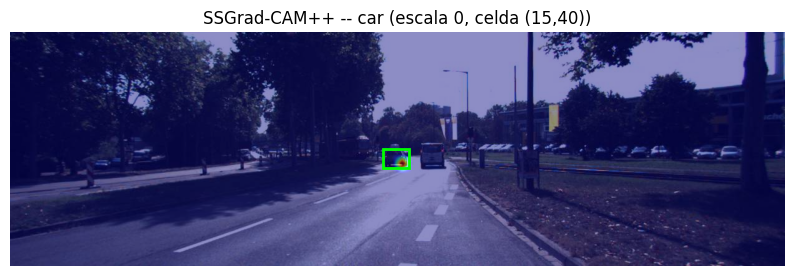

In [ ]:
def unletterbox_heatmap(heatmap_letterboxed, img1_shape, img0_shape):
    """Deshace el letterbox de Ultralytics sobre un mapa 2D, replicando la
    formula de gain/pad de ultralytics.utils.ops.scale_boxes."""
    h1, w1 = img1_shape
    h0, w0 = img0_shape
    gain = min(h1 / h0, w1 / w0)
    pad_x = round((w1 - round(w0 * gain)) / 2 - 0.1)
    pad_y = round((h1 - round(h0 * gain)) / 2 - 0.1)
    cropped = heatmap_letterboxed[pad_y:h1 - pad_y, pad_x:w1 - pad_x]
    return cv2.resize(cropped, (w0, h0))

L_c_det = F.relu((w_k.view(-1, 1, 1) * A_k * S_k_spatial).sum(dim=0))
heatmap = L_c_det.detach().cpu().numpy()

img1_shape = imgs_tensor.shape[2:]
heatmap_letterboxed = cv2.resize(heatmap, (img1_shape[1], img1_shape[0]))
heatmap_orig = unletterbox_heatmap(heatmap_letterboxed, img1_shape, orig_shape)
heatmap_norm = heatmap_orig / (heatmap_orig.max() + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.imshow(heatmap_norm, cmap="jet", alpha=0.45)
x1, y1, x2, y2 = target_box.tolist()
plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
plt.title(f"SSGrad-CAM++ -- {KITTI_CLASSES.get(target_class)} (escala {scale_idx}, celda ({row},{col}))")
plt.axis("off")
plt.show()

Agrupamos todos los pasos anteriores en una única función (`explain_detection`), para poder
explicar cualquier detección nueva sin repetir manualmente todo el proceso.

In [ ]:
def explain_detection(image_id: str, obj_idx: int, margin: int = 0, show: bool = True):
    img_bgr_ = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    orig_shape_ = img_bgr_.shape[:2]
    imgs_tensor_ = model_prep.predictor.preprocess([img_bgr_])

    dets_ = get_one2many_predictions(model_dense, imgs_tensor_, [orig_shape_], conf_thres=CONF_THRES, iou_thres=IOU_THRES_NMS)
    det_ = dets_[0]
    if obj_idx >= len(det_.boxes):
        raise IndexError(f"{image_id}: solo hay {len(det_.boxes)} detecciones, se pidio el indice {obj_idx}")

    target_box_ = det_.boxes[obj_idx]
    target_class_ = int(det_.class_probs[obj_idx].argmax())

    model_dense.model.zero_grad(set_to_none=True)
    anchor_idx_ = locate_anchor(model_dense, imgs_tensor_, orig_shape_, target_box_.tolist(), target_class_)
    scale_idx_, row_, col_, H_s_, W_s_ = anchor_index_to_cell(anchor_idx_, activations)
    M_mask_ = build_instance_mask(H_s_, W_s_, row_, col_, margin=margin, device=activations[scale_idx_].device)

    model_dense.model.zero_grad(set_to_none=True)
    _ = dense_forward_with_grad(model_dense, imgs_tensor_)
    S_c_ = logits[scale_idx_][0, target_class_, row_, col_]
    S_c_.backward()

    grad_A_ = activations[scale_idx_].grad[0]
    A_k_ = activations[scale_idx_][0].detach()
    grad_abs_ = grad_A_.abs()
    S_k_spatial_ = grad_abs_ / grad_abs_.amax(dim=(1, 2), keepdim=True).clamp(min=1e-12)

    grad2_, grad3_ = grad_A_ ** 2, grad_A_ ** 3
    masked_sum_ = (A_k_ * M_mask_.unsqueeze(0)).sum(dim=(1, 2), keepdim=True)
    denom_ = 2 * grad2_ * M_mask_.unsqueeze(0) + masked_sum_ * grad3_
    alpha_ = grad2_ / (denom_ + EPS)
    w_k_ = (alpha_ * grad_A_.clamp(min=0)).sum(dim=(1, 2))

    L_ = F.relu((w_k_.view(-1, 1, 1) * A_k_ * S_k_spatial_).sum(dim=0)).detach().cpu().numpy()
    img1_shape_ = imgs_tensor_.shape[2:]
    L_letterboxed_ = cv2.resize(L_, (img1_shape_[1], img1_shape_[0]))
    heatmap_ = unletterbox_heatmap(L_letterboxed_, img1_shape_, orig_shape_)
    heatmap_norm_ = heatmap_ / (heatmap_.max() + 1e-12)

    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(img_bgr_, cv2.COLOR_BGR2RGB))
        plt.imshow(heatmap_norm_, cmap="jet", alpha=0.45)
        bx1, by1, bx2, by2 = target_box_.tolist()
        plt.gca().add_patch(plt.Rectangle((bx1, by1), bx2 - bx1, by2 - by1, fill=False, edgecolor="lime", linewidth=2))
        plt.title(f"{image_id} obj {obj_idx}: {KITTI_CLASSES.get(target_class_)} "
                  f"(escala {scale_idx_}, celda ({row_},{col_}), margin={margin})")
        plt.axis("off")
        plt.show()

    return {
        "image_id": image_id, "obj_idx": obj_idx, "target_class": target_class_,
        "target_box": target_box_.tolist(), "scale_idx": scale_idx_, "row": row_, "col": col_,
        "heatmap": heatmap_norm_, "img_bgr": img_bgr_, "orig_shape": orig_shape_,
        "heatmap_raw": L_,                
        "w_k": w_k_.detach().cpu(),       
    }

Aplicamos el método a varios objetos: un coche, un peatón, y algunos casos con varios
objetos de la misma clase en la imagen — incluido el caso de un ciclista pequeño.

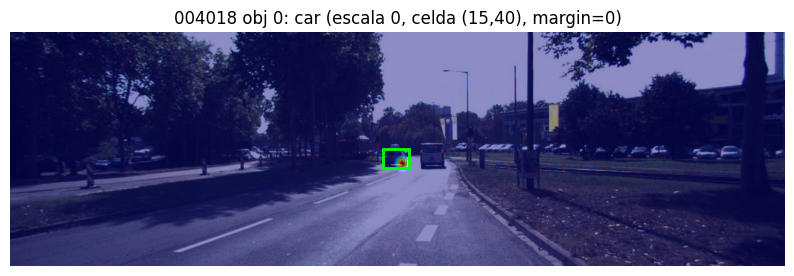

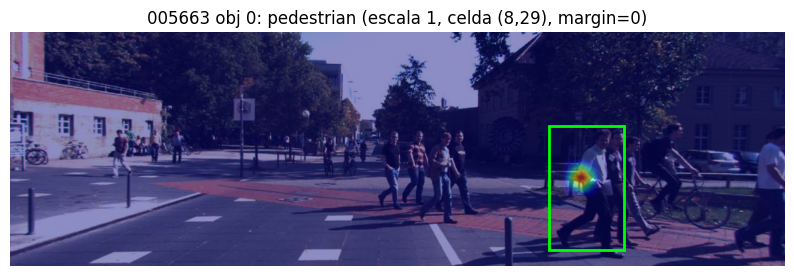

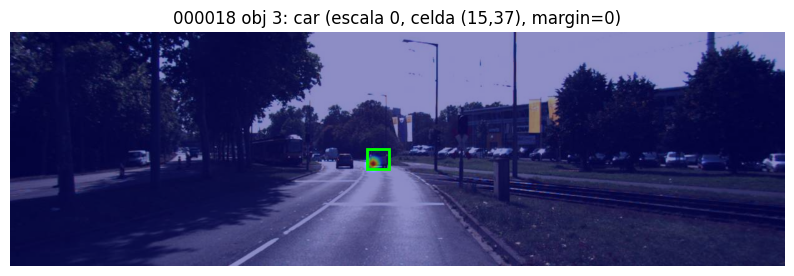

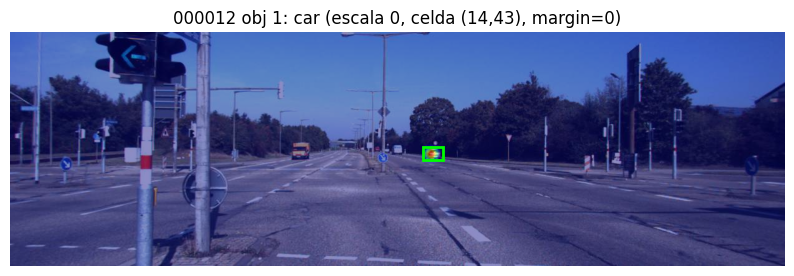

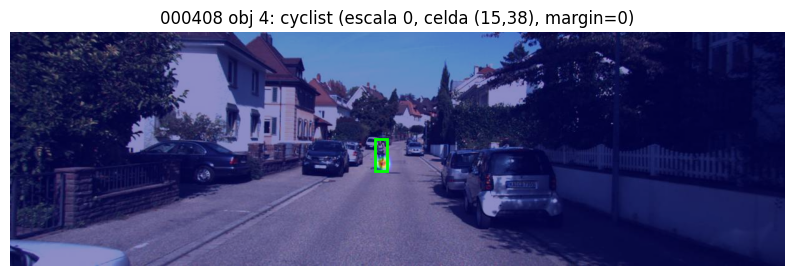

In [ ]:
result_a = explain_detection("004018", 0)
result_b = explain_detection("005663", 0)
result_c = explain_detection("000018", 3)
result_d = explain_detection("000012", 1)
result_small = explain_detection("000408", 4)  


Tapamos con gris la zona que el mapa de calor marca como más importante y volvemos a
preguntarle al modelo. Si el mapa señala de verdad lo relevante, la confianza debería bajar
al taparla — y así ocurre: baja de 0.888 a 0.765, confirmando que el
mapa apunta a algo real y no a ruido.

In [ ]:
def confidence_drop_test(result: dict, top_fraction: float = 0.2):
    img_bgr_ = result["img_bgr"].copy()
    x1, y1, x2, y2 = [int(v) for v in result["target_box"]]
    heatmap_roi = result["heatmap"][y1:y2, x1:x2]
    if heatmap_roi.size == 0:
        raise ValueError("Caja fuera de rango")

    threshold = np.quantile(heatmap_roi, 1 - top_fraction)
    mask_roi = heatmap_roi >= threshold

    perturbed = img_bgr_.copy()
    roi = perturbed[y1:y2, x1:x2]
    roi[mask_roi] = 114  
    perturbed[y1:y2, x1:x2] = roi

    imgs_tensor_orig_ = model_prep.predictor.preprocess([img_bgr_])
    imgs_tensor_pert_ = model_prep.predictor.preprocess([perturbed])

    with torch.no_grad():
        det_orig = get_one2many_predictions(model_dense, imgs_tensor_orig_, [result["orig_shape"]], conf_thres=0.0, iou_thres=IOU_THRES_NMS)[0]
        det_pert = get_one2many_predictions(model_dense, imgs_tensor_pert_, [result["orig_shape"]], conf_thres=0.0, iou_thres=IOU_THRES_NMS)[0]

    target = torch.tensor([result["target_box"]], device=DEVICE, dtype=torch.float32)

    def best_conf_for_target(det):
        if len(det.boxes) == 0:
            return 0.0
        ious = box_iou(det.boxes, target).squeeze(-1)
        idx = ious.argmax()
        return det.class_probs[idx, result["target_class"]].item() if ious[idx] >= 0.5 else 0.0

    conf_before, conf_after = best_conf_for_target(det_orig), best_conf_for_target(det_pert)
    drop_pct = 100 * max(0, conf_before - conf_after) / max(conf_before, 1e-9)
    print(f"Confianza antes: {conf_before:.4f}  despues: {conf_after:.4f}  caida: {drop_pct:.1f}%")
    return conf_before, conf_after, drop_pct

confidence_drop_test(result_a)

Confianza antes: 0.8876  despues: 0.7654  caida: 13.8%


(0.8876285552978516, 0.7653771042823792, 13.77281637525168)

Repetimos la visualización, pero recortando la imagen alrededor del objeto en vez de mostrar
la foto entera. Al hacerlo así, el mapa de calor se ve con zoom.

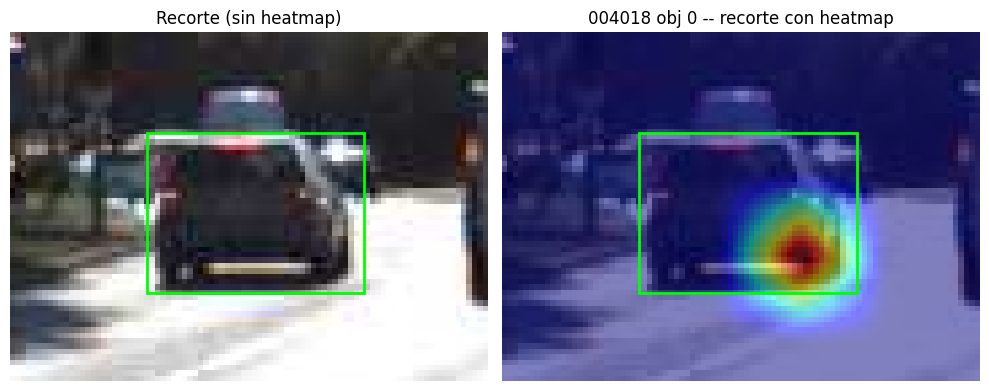

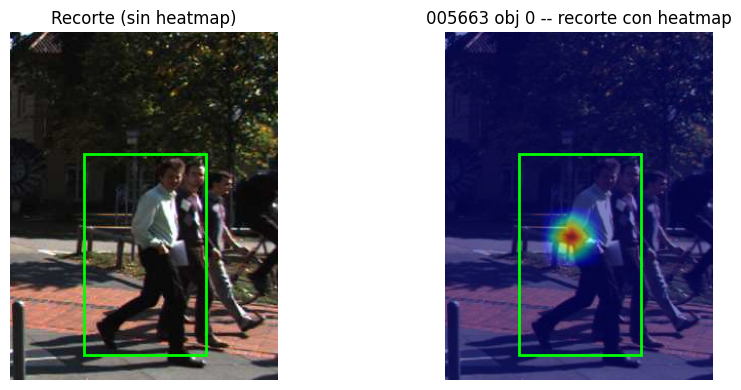

In [44]:
def plot_zoomed(result, pad_frac=0.6):
    x1, y1, x2, y2 = result["target_box"]
    w, h = x2 - x1, y2 - y1
    pad_x, pad_y = w * pad_frac, h * pad_frac
    H_img, W_img = result["orig_shape"]
    cx1, cy1 = max(0, int(x1 - pad_x)), max(0, int(y1 - pad_y))
    cx2, cy2 = min(W_img, int(x2 + pad_x)), min(H_img, int(y2 + pad_y))

    img_rgb = cv2.cvtColor(result["img_bgr"], cv2.COLOR_BGR2RGB)
    crop_img = img_rgb[cy1:cy2, cx1:cx2]
    crop_heat = result["heatmap"][cy1:cy2, cx1:cx2]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(crop_img)
    axes[0].add_patch(plt.Rectangle((x1 - cx1, y1 - cy1), w, h, fill=False, edgecolor="lime", linewidth=2))
    axes[0].set_title("Recorte (sin heatmap)")
    axes[0].axis("off")

    axes[1].imshow(crop_img)
    axes[1].imshow(crop_heat, cmap="jet", alpha=0.5, vmin=0, vmax=1)
    axes[1].add_patch(plt.Rectangle((x1 - cx1, y1 - cy1), w, h, fill=False, edgecolor="lime", linewidth=2))
    axes[1].set_title(f"{result['image_id']} obj {result['obj_idx']} -- recorte con heatmap")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

plot_zoomed(explain_detection("004018", 0, show=False))
plot_zoomed(explain_detection("005663", 0, show=False))

Probamos el método sobre escenas con dos objetos de la misma clase muy próximos entre sí
(dos coches, dos ciclistas y dos peatones). En cada caso generamos el mapa de calor para
cada objeto por separado y comprobamos que no se mezclan, incluso cuando están muy pegados o son cajas pequeñas.

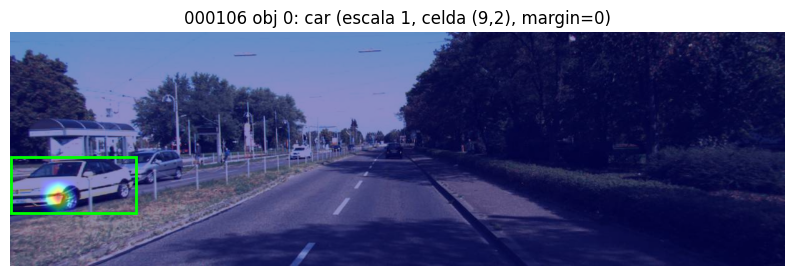

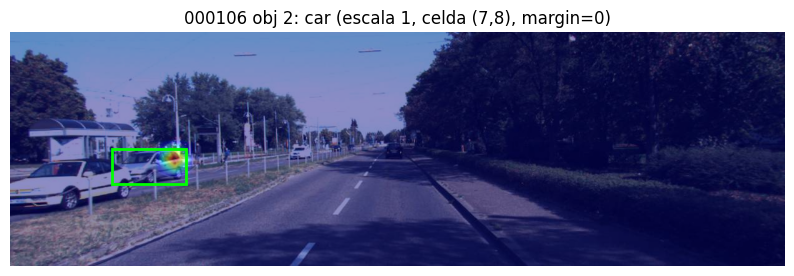

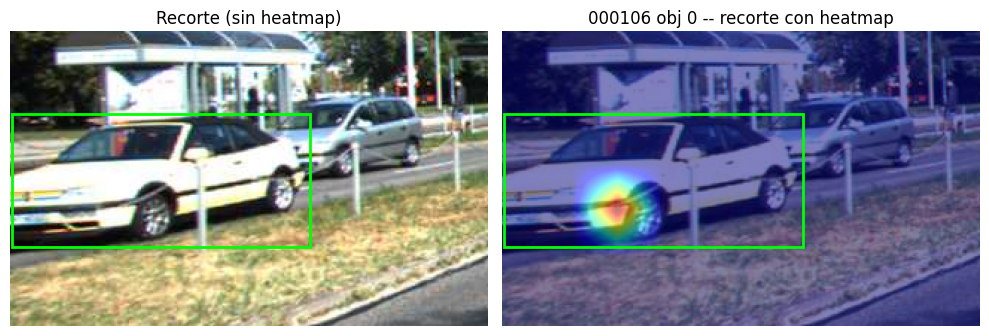

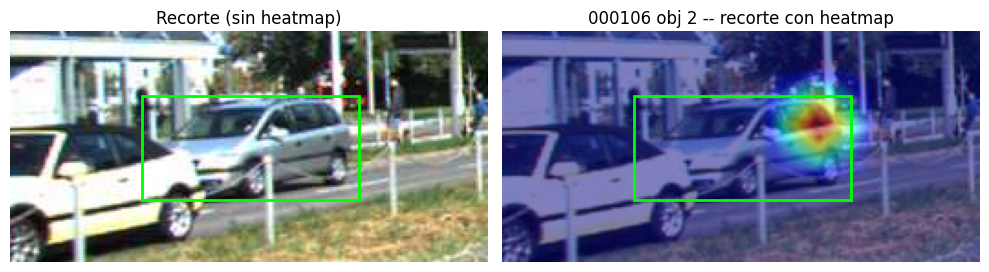

In [53]:
r1 = explain_detection("000106", 0, show=False)
r2 = explain_detection("000106", 2, show=False)
explain_detection("000106", 0)
explain_detection("000106", 2)
plot_zoomed(r1)
plot_zoomed(r2)

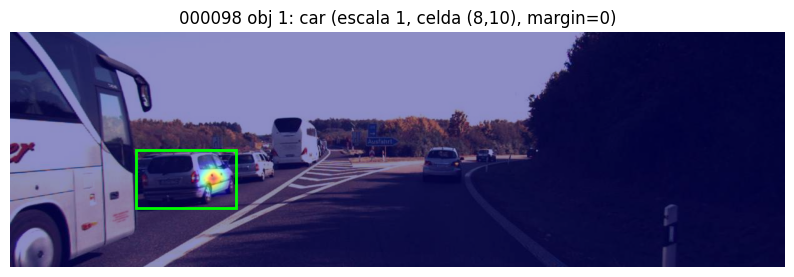

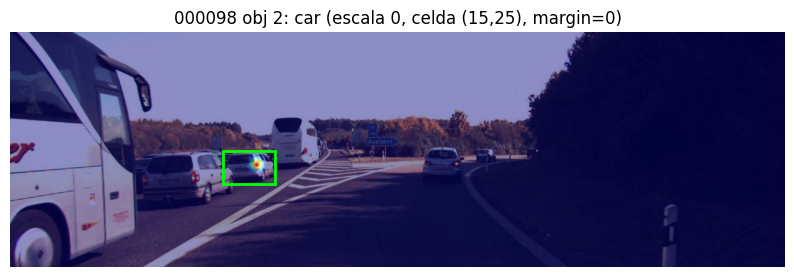

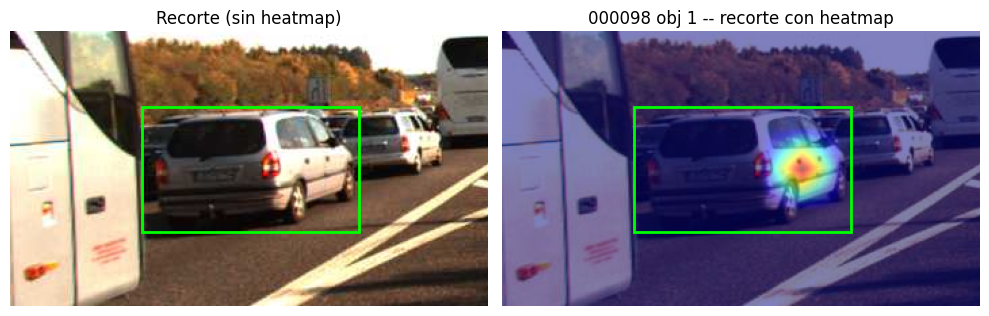

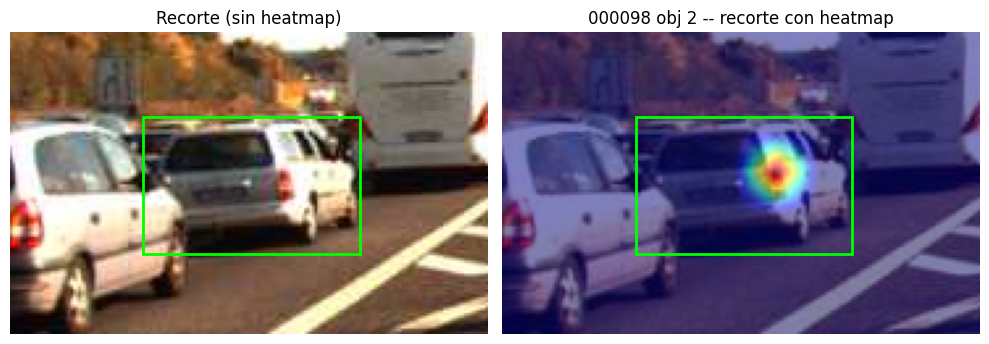

In [56]:
r1 = explain_detection("000098", 1, show=False)
r2 = explain_detection("000098", 2, show=False)
explain_detection("000098", 1)
explain_detection("000098", 2)
plot_zoomed(r1)
plot_zoomed(r2)

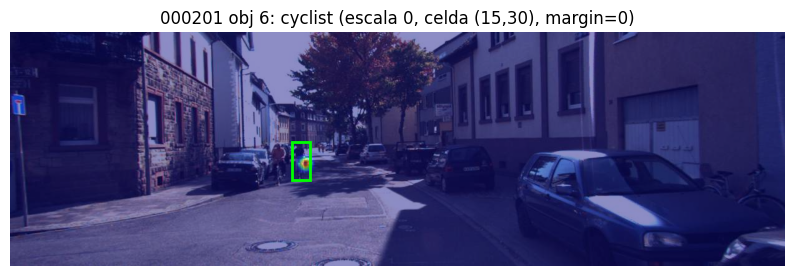

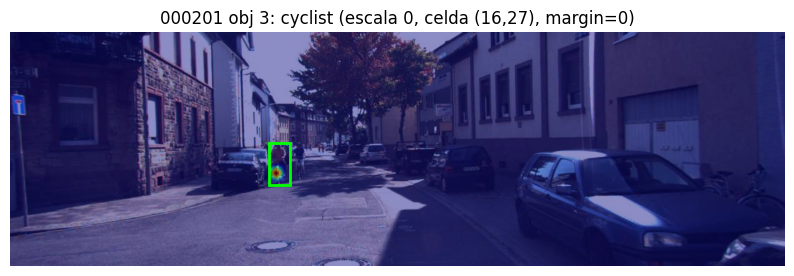

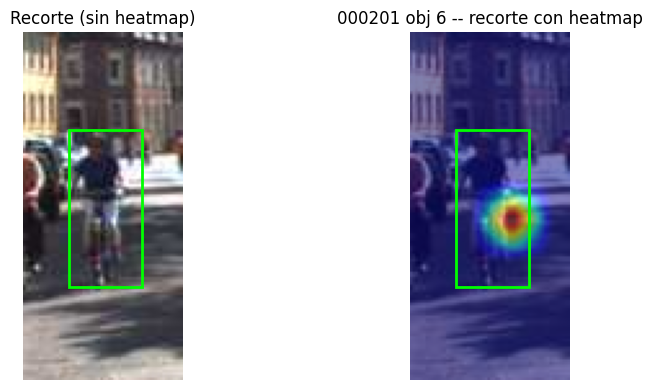

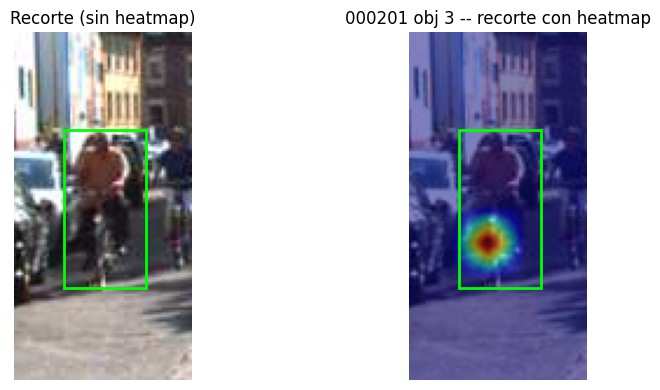

In [63]:
r1 = explain_detection("000201", 6, show=False)
r2 = explain_detection("000201", 3, show=False)
explain_detection("000201", 6)
explain_detection("000201", 3)
plot_zoomed(r1)
plot_zoomed(r2)

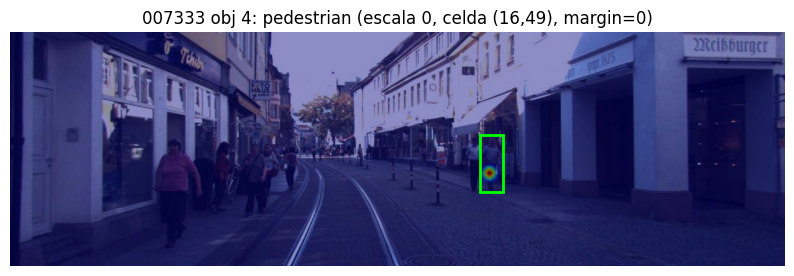

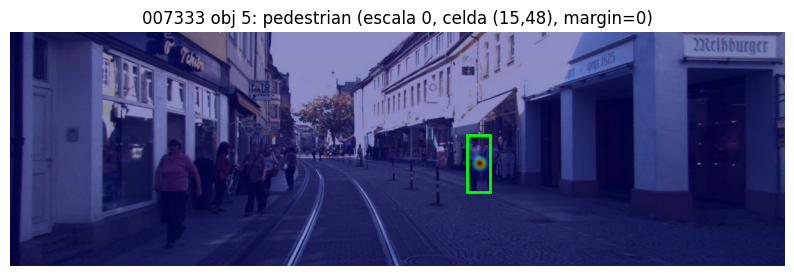

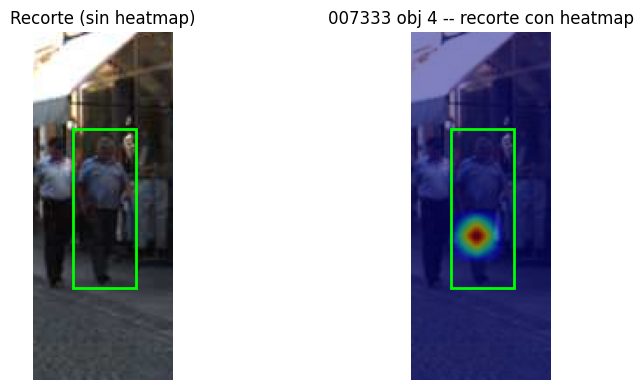

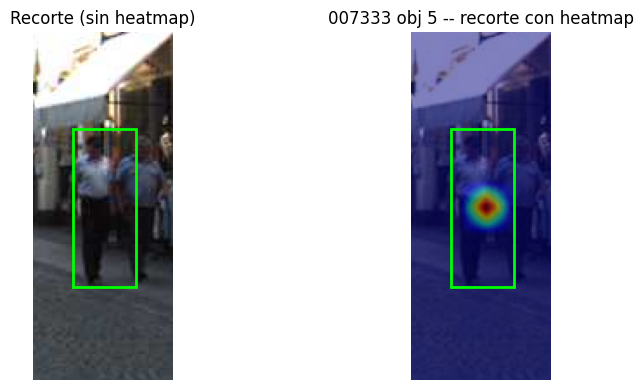

In [68]:
r1 = explain_detection("007333", 4, show=False)
r2 = explain_detection("007333", 5, show=False)
explain_detection("007333", 4)
explain_detection("007333", 5)
plot_zoomed(r1)
plot_zoomed(r2)

## Comprobación arquitectónica: ¿cambia la resolución espacial según qué sub-capa de `cv3` se elija como capa objetivo?

**Qué son `branch[0]` y `branch[1]` en la arquitectura de YOLO26.** `cv3[s]` es la rama de
clasificación de la cabeza `Detect` para la escala `s` (la contraparte de `cv2[s]`, que
regresiona la caja). Esta rama se construye como dos bloques compuestos idénticos, donde cada uno tiene una
convolución separable en profundidad seguida de una convolución regular, y una convolución
final 1×1 que proyecta a los `n_clases` logits. En el código de este proyecto
(`ssgradcampp.py` y este mismo notebook), esos tres sub-módulos se indexan como `branch[0]`
(primer bloque compuesto), `branch[1]` (segundo bloque compuesto, el que se usa actualmente
como activación $A_k$ en producción) y `branch[2]` (la convolución 1×1 final, ya usada más
arriba como $S_c$, el logit pre-sigmoide).

**Por qué solo `branch[0]` y `branch[1]` son candidatas a punto de enganche, y `branch[2]`
no.** El método necesita dos cosas distintas de la red: una activación $A_k$ con muchos
canales (interpretados como patrones visuales aprendidos, que luego se ponderan por
importancia para construir el mapa de calor) y una puntuación $S_c$ (un único escalar por
celda y clase) cuyo gradiente respecto a $A_k$ es lo que se calcula. `branch[2]` ya produce
exactamente esa puntuación (su salida tiene `n_clases` canales, uno por clase, sin ninguna
transformación adicional antes del logit): no es una activación genérica, es la puntuación
misma, así que no puede jugar a la vez el papel de $A_k$ y de $S_c$. `branch[0]` y
`branch[1]`, en cambio, todavía producen una activación genérica (muchos canales, sin
colapsar aún a puntuaciones por clase), así que ambas son candidatas legítimas para $A_k$.
Son, literalmente, las únicas dos capas de `cv3[s]` que quedan antes del logit final.

**Por qué hay tres rejillas distintas (28×80, 14×40, 7×20), y a qué corresponden en la
arquitectura.** YOLO26 detecta objetos sobre tres mapas de características de tamaños
distintos llamados P3, P4 y P5, cada uno obtenido submuestreando la imagen de entrada por
un factor distinto (paso o *stride* 8, 16 y 32, respectivamente) a través del *backbone* y el
cuello. Con el tamaño de entrada de este proyecto (imagen *letterboxed* a 224×640 píxeles),
dividir cada dimensión por el *stride* de cada escala da exactamente las tres rejillas ya
verificadas: 224/8 × 640/8 = 28×80 en P3, 224/16 × 640/16 = 14×40 en P4, y 224/32 × 640/32 =
7×20 en P5. Cada una de estas tres escalas tiene su propia instancia independiente de
`cv2`/`cv3` dentro de la cabeza `Detect`, es decir, son tres ramas de clasificación distintas, no una
compartida ya que el modelo asigna cada objeto a una escala según su tamaño (los objetos
pequeños se detectan en la rejilla fina P3, los grandes en la basta P5). La rejilla de cada
escala queda fijada por el *backbone* y el cuello, **antes** de que la activación llegue
siquiera a `cv3`; dentro de `cv3[s]` de una escala concreta, `branch[0]`, `branch[1]` y
`branch[2]` son todas convoluciones de paso 1, así que ninguna cambia esa rejilla ya fijada. Estas
solo pueden cambiar entre sí la profundidad de canal y qué información capturan. Por eso mover
el punto de enganche entre `branch[0]` y `branch[1]` no puede, por construcción, alterar la
rejilla de la escala en la que ya se está explicando esa detección; lo que sí la cambiaría
sería explicar la detección en otra escala (P3 en vez de P5), pero eso no depende de este
parámetro sino de qué escala generó el ancla de esa detección concreta.

Lo comprobamos registrando un hook temporal adicional sobre `branch[0]` de las 3 escalas (sin
tocar los hooks ya registrados sobre `branch[1]`/`branch[2]` más arriba), ejecutando un único
forward pass sobre una imagen ya usada como referencia en este notebook, y comparando las
formas de los tensores capturados. El hook temporal se retira justo después, para no dejar
efectos secundarios sobre el resto del notebook.

In [7]:
CHECK_IMAGE_ID = "004018"  

img_bgr_check = cv2.imread(str(VAL_IMAGES_DIR / f"{CHECK_IMAGE_ID}.png"))
assert img_bgr_check is not None, f"Could not read {CHECK_IMAGE_ID}"
imgs_tensor_check = model_prep.predictor.preprocess([img_bgr_check])

branch0_shapes = {}

def _branch0_shape_hook(scale_idx):
    def _hook(module, inp, out):
        branch0_shapes[scale_idx] = tuple(out.shape)
    return _hook

_temp_handles = [detect_head.cv3[s][0].register_forward_hook(_branch0_shape_hook(s)) for s in range(NUM_SCALES)]

_ = dense_forward_with_grad(model_dense, imgs_tensor_check)  

for h in _temp_handles:
    h.remove()

for s in range(NUM_SCALES):
    shape0 = branch0_shapes[s]
    shape1 = tuple(activations[s].shape)
    stride = int(detect_head.stride[s])
    print(f"Scale {s} (stride {stride}): branch[0] {shape0[1]} channels, {shape0[2]}x{shape0[3]}  |  "
          f"branch[1] {shape1[1]} channels, {shape1[2]}x{shape1[3]}")
    assert shape0[2:] == shape1[2:], (
        f"Scale {s}: branch[0] and branch[1] return different spatial resolutions "
    )

print("branch[0] and branch[1] share spatial resolution (H x W) across all 3 scales.")

Scale 0 (stride 8): branch[0] 64 channels, 28x80  |  branch[1] 64 channels, 28x80
Scale 1 (stride 16): branch[0] 64 channels, 14x40  |  branch[1] 64 channels, 14x40
Scale 2 (stride 32): branch[0] 64 channels, 7x20  |  branch[1] 64 channels, 7x20
branch[0] and branch[1] share spatial resolution (H x W) across all 3 scales.


## Barrido margin x activation_layer_idx

**`margin`:** Cuando SSGrad-CAM++ explica una
deteccion concreta, restringe el calculo a la celda de la rejilla (P3, P4 o P5, segun la
escala que generó esa deteccion) de la que nace esa deteccion (eso es la mascara $\mu^d$
(binaria) que ya se construyó mas arriba en este notebook). Con
`margin=0` (el valor de produccion), esa mascara activa una unica celda. `margin=k` la amplia
a una ventana de $(2k+1)\times(2k+1)$ celdas alrededor de esa misma celda central, dentro de la
misma escala. Solo cambia cuantas de esas celdas, ya
existentes, entran en el promedio ponderado que construye el *heatmap*. Es, por tanto, un
parametro del metodo de explicacion (cuanto contexto espacial alrededor del ancla se deja
influir en la explicacion), no un parametro de la arquitectura de YOLO26 en si.

**`activation_layer_idx`:** `cv3[s]` es la rama de
clasificacion de la cabeza `Detect` de YOLO26 para la escala `s`: 
dos bloques compuestos de paso 1 (`branch[0]`, `branch[1]`, cada uno una
convolucion separable en profundidad seguida de una convolucion regular, segun el diagrama de
bloques del paper oficial de YOLO26) seguidos de la convolucion final 1x1 que proyecta a los
logits por clase (`branch[2]`, ya usada como la puntuacion $S_c$). `activation_layer_idx`
decide cual de esas dos primeras sub-capas (`branch[0]` o `branch[1]`) se engancha como la
activacion $A_k$ que SSGrad-CAM++ diferencia y pondera por canal para construir el *heatmap*. 

Experimento: 8 combinaciones de `margin` en {0,1,2,3} x `activation_layer_idx` en {0,1} sobre 20 imagenes de
validacion (las 4 ya usadas como referencia en este notebook  mas 16 aleatorias. Para cada objeto detectado en esas 20 imagenes y
cada combinacion calculamos las mismas seis metricas del benchmark principal (`pointing_game`,
`ebpg`, `relevance_rank_accuracy`, `sparseness`, `deletion_auc`, `insertion_auc`), reutilizando
las funciones de `evaluation/quantus_metrics.py` y `evaluation/detection_metrics.py`.

In [9]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd

from xai_benchmark.xai.ssgradcampp import SSGradCAMPP, AnchorNotFoundError
from xai_benchmark.evaluation import detection_metrics, quantus_metrics

EVAL_STEP = 5000  # same value already used in configs/xai/ssgradcampp.yaml (evaluation.step)

Construimos la lista de 20 imágenes: las 4 ya usadas como referencia, más 16 aleatorias del conjunto de validación (excluyéndolas), con semilla fija para reproducibilidad.

In [10]:
KNOWN_SWEEP_IMAGE_IDS = ["004018", "005663", "000408", "000106"]
N_RANDOM_SWEEP_IMAGES = 16

all_val_images = sorted(p.stem for p in VAL_IMAGES_DIR.glob("*.png"))
candidate_images = [img_id for img_id in all_val_images if img_id not in KNOWN_SWEEP_IMAGE_IDS]
random_sweep_image_ids = random.Random(SEED).sample(candidate_images, N_RANDOM_SWEEP_IMAGES)

SWEEP_IMAGE_IDS = KNOWN_SWEEP_IMAGE_IDS + random_sweep_image_ids
print(f"{len(SWEEP_IMAGE_IDS)} images for the sweep: {SWEEP_IMAGE_IDS}")

20 images for the sweep: ['004018', '005663', '000408', '000106', '004019', '004382', '000420', '002662', '005217', '005035', '004240', '003134', '004939', '003696', '005908', '002267', '005168', '001534', '002887', '001548']


Las detecciones de cada imagen no dependen de `margin` ni de `activation_layer_idx`, así que las calculamos una única vez por imagen y las reutilizamos en las 8 combinaciones, en vez de repetir el forward pass del detector 8 veces por nada.

In [11]:
sweep_cache = {}

for image_id in SWEEP_IMAGE_IDS:
    img_bgr_s = cv2.imread(str(VAL_IMAGES_DIR / f"{image_id}.png"))
    if img_bgr_s is None:
        print(f"WARNING: could not read {image_id}, skipping")
        continue
    orig_shape_s = img_bgr_s.shape[:2]
    imgs_tensor_s = model_prep.predictor.preprocess([img_bgr_s])
    dets_s = get_one2many_predictions(model_dense, imgs_tensor_s, [orig_shape_s],
                                       conf_thres=CONF_THRES, iou_thres=IOU_THRES_NMS)[0]
    if len(dets_s.boxes) == 0:
        print(f"WARNING: no detections in {image_id}, skipping")
        continue
    objects_s = [(i, dets_s.boxes[i].tolist(), int(dets_s.class_probs[i].argmax()))
                 for i in range(len(dets_s.boxes))]
    sweep_cache[image_id] = {
        "img_bgr": img_bgr_s, "orig_shape": orig_shape_s,
        "imgs_tensor": imgs_tensor_s, "letterbox_shape": tuple(imgs_tensor_s.shape[2:]),
        "objects": objects_s,
    }

n_objects_total = sum(len(v["objects"]) for v in sweep_cache.values())
print(f"{len(sweep_cache)} images with detections, {n_objects_total} objects total "
      f"-> {n_objects_total * 8} (object, combination) evaluations ahead.")

19 images with detections, 95 objects total -> 760 (object, combination) evaluations ahead.


El bucle exterior es activation_layer_idx (fija los hooks al construir SSGradCAMPP); el interior es margin (argumento de .explain, no requiere reconstruir nada). Guardamos también el resultado completo (con heatmap) de los 4 objetos de referencia.

In [12]:
REFERENCE_OBJECTS = {"004018": 0, "005663": 0, "000408": 4, "000106": 0}

sweep_rows = []
reference_results = {} 

for activation_layer_idx in (1, 0):
    explainer = SSGradCAMPP.from_checkpoint(CHECKPOINT, device=DEVICE, activation_layer_idx=activation_layer_idx)

    for image_id, cached in sweep_cache.items():
        img_bgr_s = cached["img_bgr"]
        orig_shape_s = cached["orig_shape"]
        letterbox_shape_s = cached["letterbox_shape"]
        x_np_s = cached["imgs_tensor"].cpu().numpy().astype(np.float32)

        for obj_idx, target_box, target_class in cached["objects"]:
            for margin in (0, 1, 2, 3):
                try:
                    result = explainer.explain(img_bgr_s, target_box, target_class, margin=margin)
                except AnchorNotFoundError as e:
                    print(f"WARNING: {image_id} obj {obj_idx} (layer={activation_layer_idx}, margin={margin}): {e}")
                    continue

                heatmap_orig = detection_metrics.reconstruct_heatmap_original(
                    result.heatmap_raw, letterbox_shape_s, orig_shape_s)
                box_mask = detection_metrics.build_box_mask(target_box, *orig_shape_s)

                heatmap_lb = detection_metrics.reconstruct_heatmap_letterboxed(
                    result.heatmap_raw, letterbox_shape_s)
                classifier = detection_metrics.DetectorAsClassifier(
                    model_dense, NUM_CLASSES, orig_shape_s, target_box, target_class,
                    conf_thres=CONF_THRES, iou_thres_nms=IOU_THRES_NMS)
                aucs = detection_metrics.deletion_insertion_auc(
                    classifier, x_np_s, heatmap_lb, target_class, step=EVAL_STEP, device=DEVICE)

                sweep_rows.append({
                    "image_id": image_id, "obj_idx": obj_idx,
                    "pred_class": target_class, "pred_class_name": KITTI_CLASSES.get(target_class, "?"),
                    "scale_idx": result.scale_idx,
                    "activation_layer_idx": activation_layer_idx, "margin": margin,
                    "pointing_game": quantus_metrics.pointing_game(heatmap_orig, box_mask),
                    "ebpg": quantus_metrics.energy_based_pointing_game(heatmap_orig, box_mask),
                    "relevance_rank_accuracy": quantus_metrics.relevance_rank_accuracy(heatmap_orig, box_mask),
                    "sparseness": quantus_metrics.sparseness(heatmap_orig),
                    "deletion_auc": aucs["deletion_auc"],
                    "insertion_auc": aucs["insertion_auc"],
                })

                if REFERENCE_OBJECTS.get(image_id) == obj_idx:
                    reference_results[(image_id, activation_layer_idx, margin)] = result

    explainer.remove_hooks()
    del explainer
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"Done: {len(sweep_rows)} (object, combination) rows.")

c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Ratio is smaller than max size.")
c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Ratio is smaller than max size.")
c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Ratio is smaller than max size.")
c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Ratio is smaller than max size.")
c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Rati

Done: 760 (object, combination) rows.


c:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\.venv\Lib\site-packages\quantus\helpers\warn.py:271: UserWarning: Ratio is smaller than max size.
  warnings.warn("Ratio is smaller than max size.")


Guardamos la tabla completa y mostramos la media de las seis métricas por combinación.

In [13]:
SWEEP_OUTPUT_DIR = REPO_ROOT / "results" / "ssgradcampp_sweep"
SWEEP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(SWEEP_OUTPUT_DIR / "metrics.csv", index=False)

METRIC_COLS = ["pointing_game", "ebpg", "relevance_rank_accuracy", "sparseness", "deletion_auc", "insertion_auc"]
summary = sweep_df.groupby(["activation_layer_idx", "margin"])[METRIC_COLS].mean().round(4)
summary

pointing_game    ebpg  relevance_rank_accuracy  \
activation_layer_idx margin                                                   
0                    0              0.7789  0.7030                   0.5773   
                     1              1.0000  0.7523                   0.6434   
                     2              1.0000  0.7618                   0.6413   
                     3              0.9579  0.7598                   0.6041   
1                    0              1.0000  0.9050                   0.3781   
                     1              1.0000  0.9050                   0.3781   
                     2              1.0000  0.9050                   0.3781   
                     3              1.0000  0.9050                   0.3781   

                             sparseness  deletion_auc  insertion_auc  
activation_layer_idx margin                                           
0                    0           0.9899        0.1618         0.6654  
                     1           0.9895        0.1613         0.6780  
                     2           0.9899        0.1625         0.6766  
                     3           0.9839        0.1734         0.6700  
1                    0           0.9971        0.2876         0.5890  
                     1           0.9971        0.2876         0.5890  
                     2           0.9971        0.2876         0.5890  
                     3           0.9971        0.2876         0.5890

Comparación visual

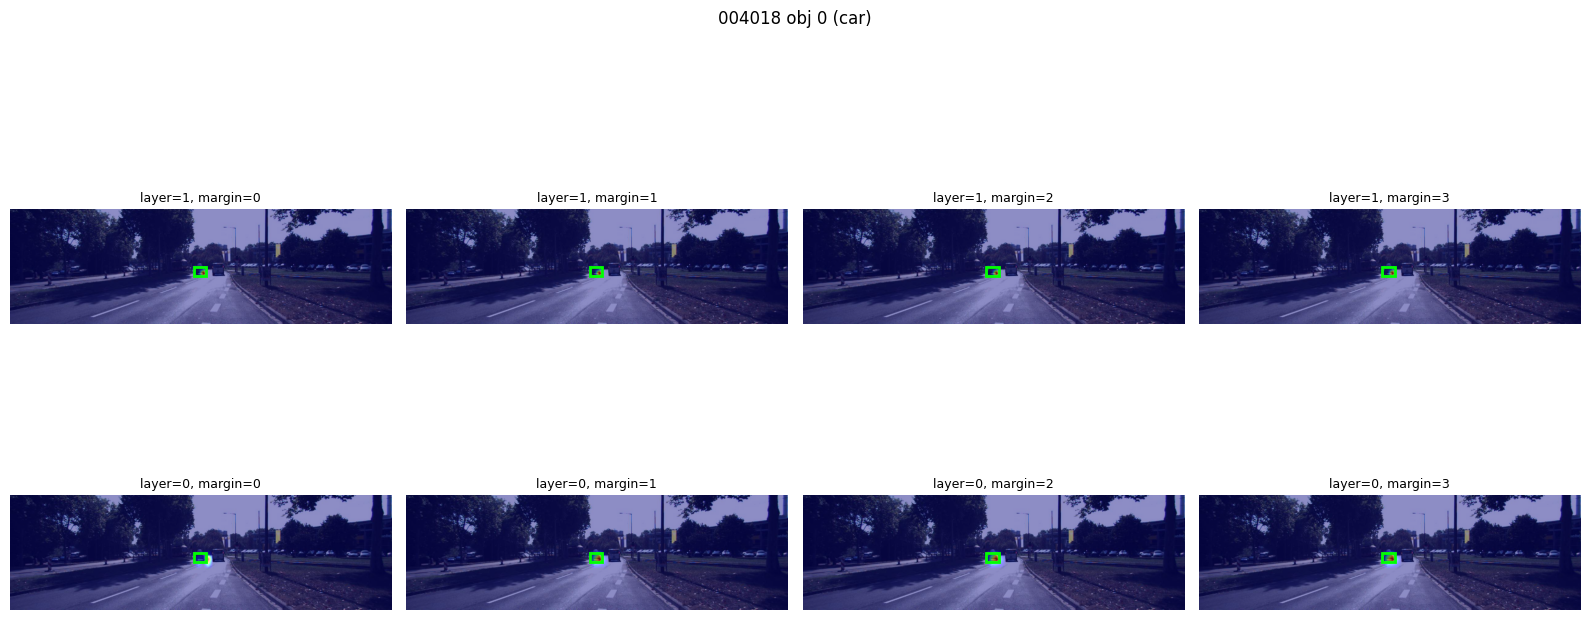

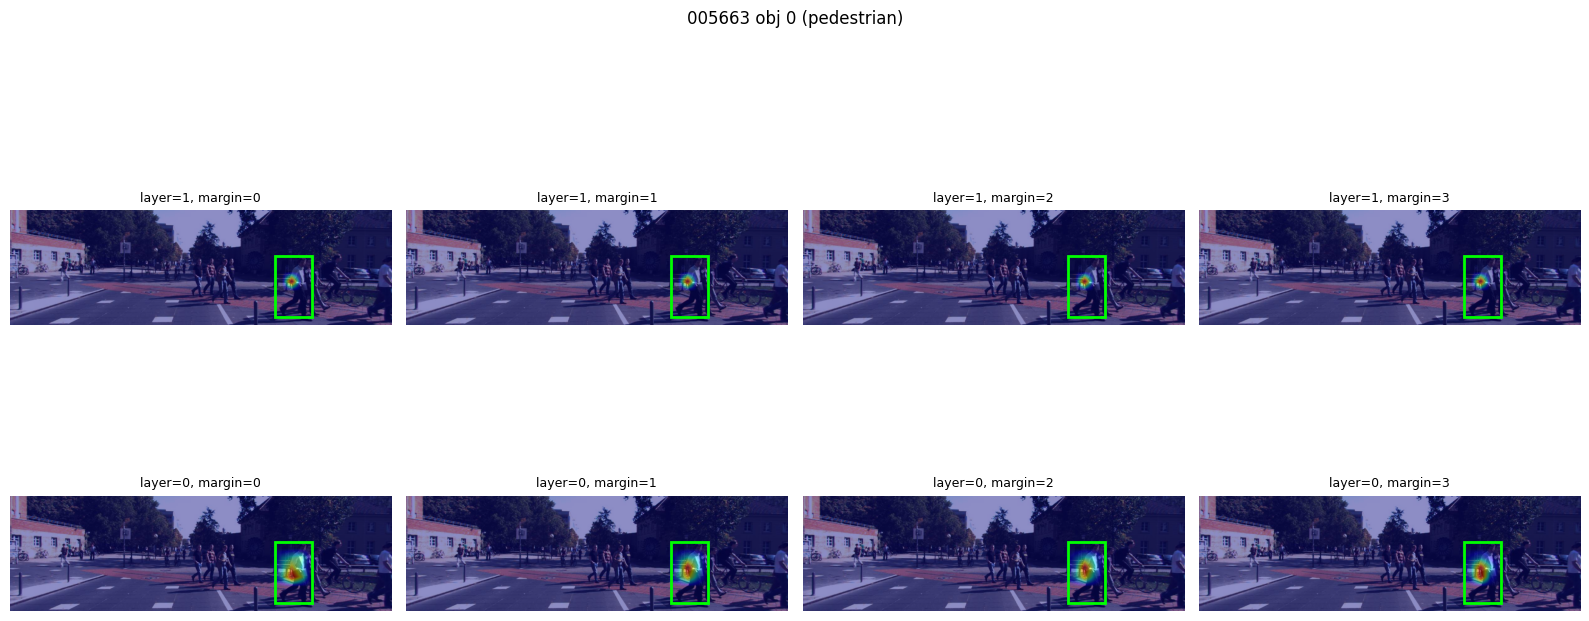

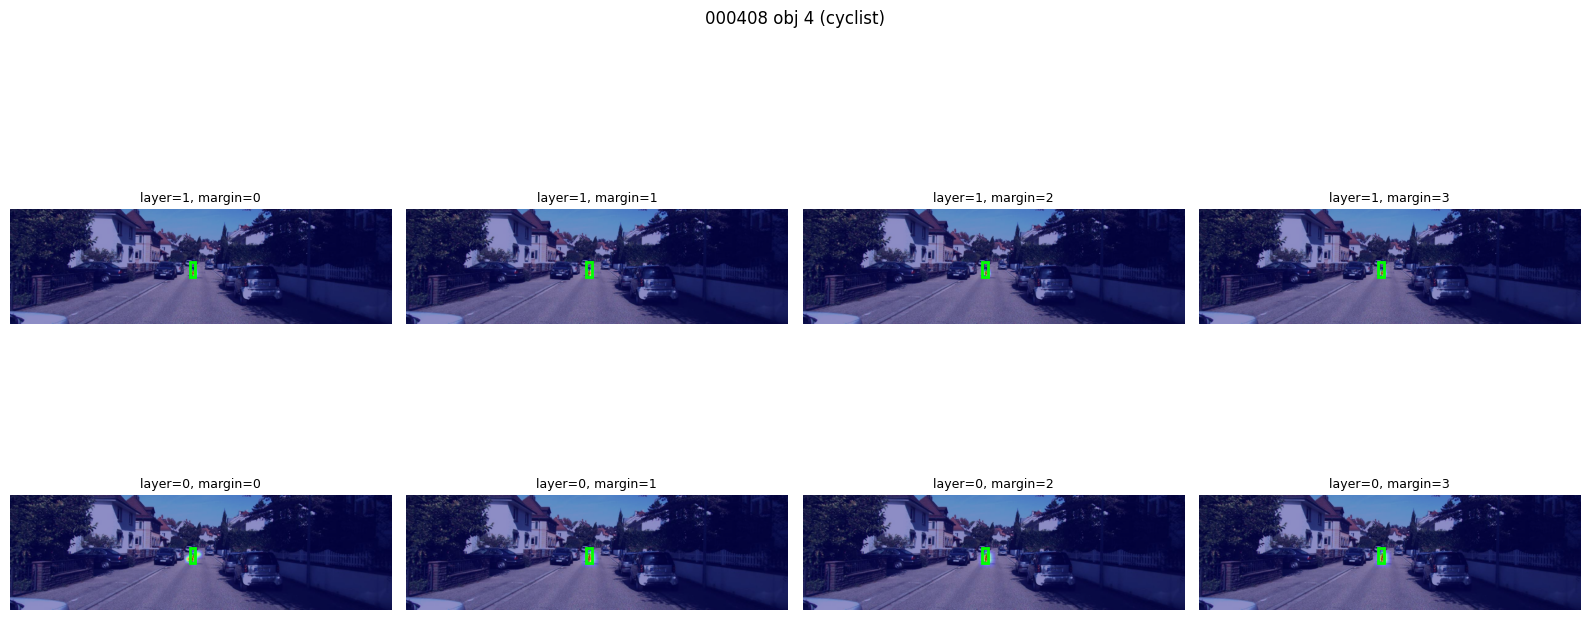

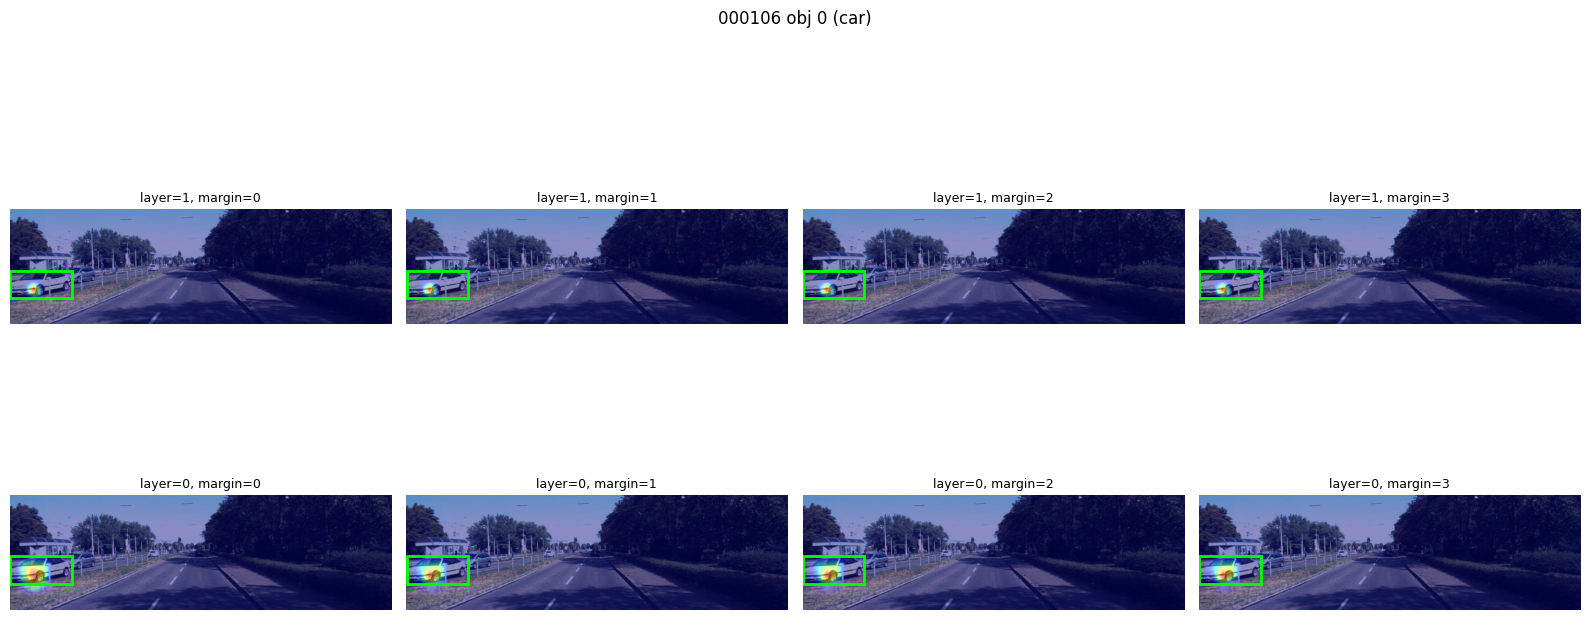

Saved 4 comparison grids in C:\Users\alber\OneDrive\Escritorio\Máster\TFM\TFM_codigo\results\ssgradcampp_sweep\heatmaps


In [14]:
HEATMAPS_DIR = SWEEP_OUTPUT_DIR / "heatmaps"
HEATMAPS_DIR.mkdir(parents=True, exist_ok=True)

for image_id, ref_obj_idx in REFERENCE_OBJECTS.items():
    img_rgb_r = cv2.cvtColor(sweep_cache[image_id]["img_bgr"], cv2.COLOR_BGR2RGB)
    ref_class = reference_results[(image_id, 1, 0)].target_class

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for row_idx, activation_layer_idx in enumerate((1, 0)):
        for col_idx, margin in enumerate((0, 1, 2, 3)):
            result = reference_results[(image_id, activation_layer_idx, margin)]
            ax = axes[row_idx, col_idx]
            ax.imshow(img_rgb_r)
            ax.imshow(result.heatmap, cmap="jet", alpha=0.45)
            x1, y1, x2, y2 = result.target_box
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
            ax.set_title(f"layer={activation_layer_idx}, margin={margin}", fontsize=9)
            ax.axis("off")

    fig.suptitle(f"{image_id} obj {ref_obj_idx} ({KITTI_CLASSES.get(ref_class, '?')})")
    fig.tight_layout()
    fig.savefig(HEATMAPS_DIR / f"{image_id}_obj{ref_obj_idx}_sweep.png", dpi=150)
    plt.show()

print(f"Saved 4 comparison grids in {HEATMAPS_DIR}")